Rows: 254 Columns: 404
-- Column specification --------------------------------------------------------
Delimiter: ","
chr   (1): County
dbl (380): cve, outbreak, enrollment, PHR, pct_hispanic, pct_black, pct_whit...
lgl  (23): median_income, Advised to Cut Down Salt - Do not use salt, Diabet...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"S

After Spearman screen: 220 candidates
# A tibble: 220 x 3
   variable                                                   rho     p_value
   <chr>                                                    <dbl>       <dbl>
 1 Mammogram Past 2 Yrs 40+ IA - No                         0.311 0.000000415
 2 Mammogram Past 2 Yrs 40+ IA - Yes                       -0.311 0.000000415
 3 Mammogram Past 2 Yrs 50+ IA - Yes                       -0.309 0.000000527
 4 Mammogram Past 2 Yrs 50+ IA - No                         0.309 0.000000527
 5 Poor Mental Health 14+ Days - None to less than 14 days  0.306 0.000000664
 6 Poor Mental Health 14+ Days - 14 or more days           -0.306 0.000000664
 7 Sigm Past 5 Yrs Age 50-75 - No                           0.301 0.00000101 
 8 Sigm Past 5 Yrs 50-75 IA - No                            0.301 0.00000101 
 9 Depressive Disorder - No                                 0.292 0.00000222 
10 Depressive Disorder - Yes                               -0.292 0.00000222 
# i 21

 Family: nbinom2  ( log )
Formula:          
outbreak ~ cve + `Smokeless Tobacco Use - Every day` + `Current E-cig User - Yes` +  
    `ClnscpySgmscpy - Both` + `RxPainRiskEd Source - Yes` + `COPD - Yes` +  
    `Cervical Cancer Screening Pa - No` + pct_uninsured + `Stool DNA Past 3 Yrs Age 50- - Yes` +  
    pct_white + offset(log(enrollment)) + (1 | PHR)
Data: model_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    372.6     418.4    -173.3     346.6       236 

Random effects:

Conditional model:
 Groups Name        Variance  Std.Dev. 
 PHR    (Intercept) 6.181e-09 7.862e-05
Number of obs: 249, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.161 

Conditional model:
                                       Estimate Std. Error z value Pr(>|z|)   
(Intercept)                          -13.075928   9.893765  -1.322  0.18629   
cve                                    0.360392   0.184301   1.955  0.05053 . 
`Smokeless Tobacco Use - Every day`    0.683259   0.722802  

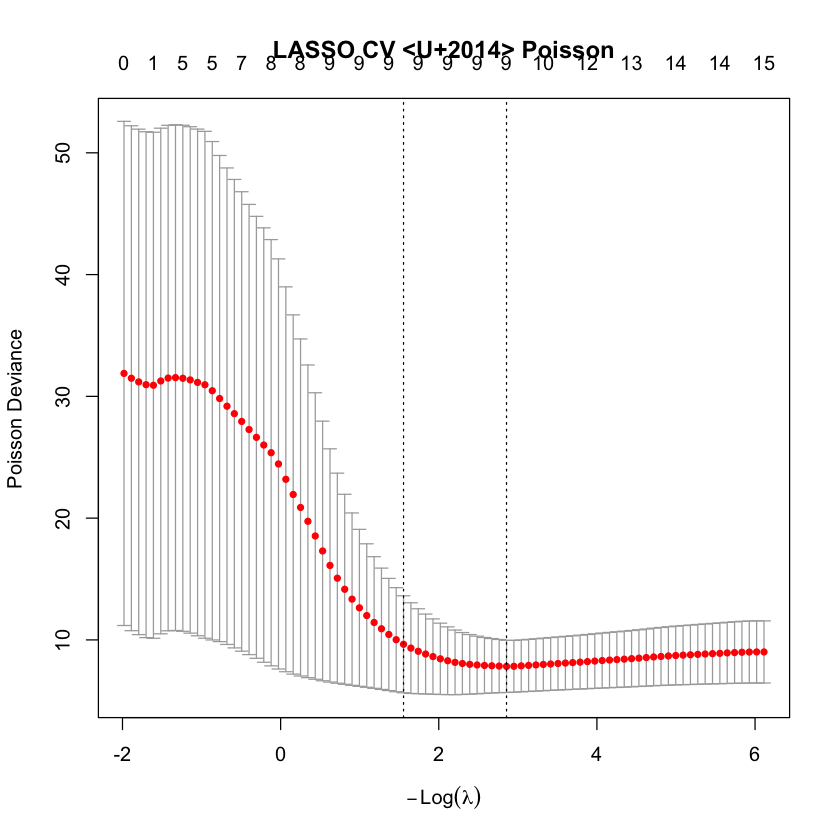

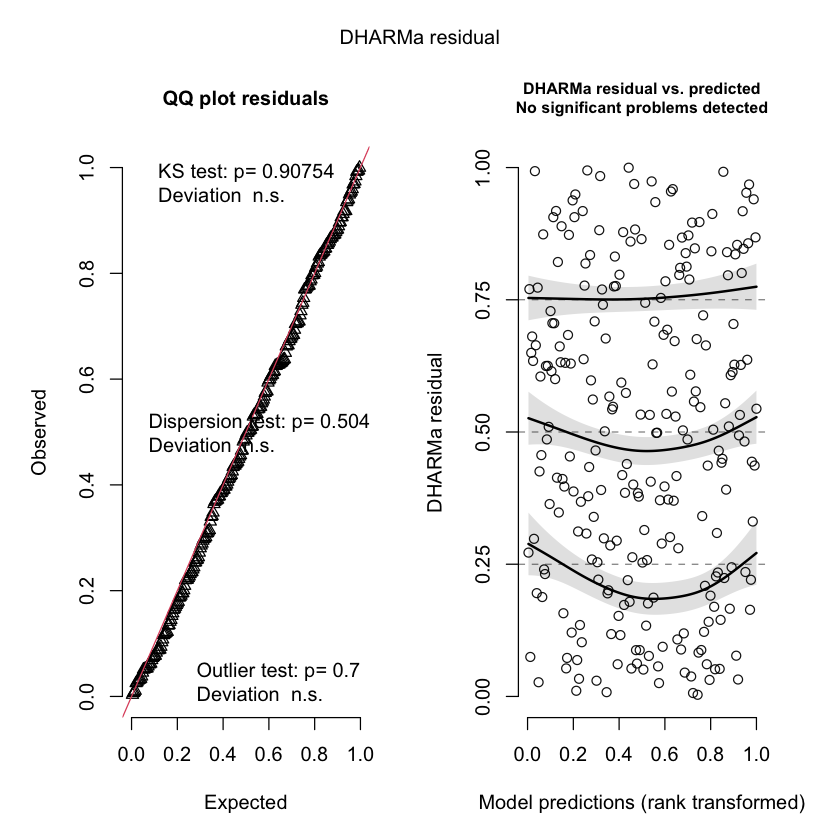

In [19]:
 
library(tidyverse)
library(glmnet)
library(glmmTMB)
library(caret)
library(DHARMa)
 
 
# ── 0. Load data ──────────────────────────────────────────────────────────────
 
df <- read_csv("data/merged_data.csv")
 
 
# ── 1. Define outcome, offset, grouping, and covariate matrix ─────────────────
 
outcome    <- df$outbreak
offset_var <- log(df$enrollment)
PHR        <- df$PHR
 
# All columns except identifiers and the two outcomes
X_all <- df %>%
  select(-County, -cve, -outbreak, -enrollment, -PHR) %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  mutate(across(everything(), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))
 
 
# ── 2. Spearman screen  (keep p < 0.2) ───────────────────────────────────────
 
spearman_screen <- function(X, y, p_threshold = 0.2) {
  map_dfr(names(X), function(var) {
    x  <- X[[var]]
    ok <- !is.na(x) & !is.na(y)
    if (sum(ok) < 10) return(NULL)
    test <- cor.test(x[ok], y[ok], method = "spearman", exact = FALSE)
    tibble(variable = var, rho = test$estimate, p_value = test$p.value)
  }) %>%
    filter(p_value < p_threshold) %>%
    arrange(p_value)
}
 
candidates <- spearman_screen(X_all, outcome)
cat("After Spearman screen:", nrow(candidates), "candidates\n")
print(candidates)
 
 
# ── 3. Collinearity filter  (drop variables with |r| > 0.70) ─────────────────
 
X_cand    <- X_all[, candidates$variable, drop = FALSE]
cor_mat   <- cor(X_cand, use = "pairwise.complete.obs")
to_remove <- findCorrelation(cor_mat, cutoff = 0.70, names = TRUE)
X_filt    <- X_cand[, !names(X_cand) %in% to_remove, drop = FALSE]
cat("After collinearity filter:", ncol(X_filt), "variables\n")
 
 
# ── 4. Drop rows with NA outcome or non-finite offset ────────────────────────
 
valid      <- !is.na(outcome) & is.finite(offset_var)
y          <- outcome[valid]
offs       <- offset_var[valid]
phr        <- factor(PHR[valid])
X_clean    <- X_filt[valid, , drop = FALSE]
 
 
# ── 5. LASSO  (Poisson, lambda.1se) ──────────────────────────────────────────
 
X_mat <- model.matrix(~ . - 1, data = X_clean)
 
set.seed(42)
cv_lasso <- cv.glmnet(
  x      = X_mat,
  y      = y,
  offset = offs,
  family = "poisson",
  alpha  = 1            # LASSO
)
plot(cv_lasso, main = "LASSO CV — Poisson")
 
lasso_coef <- coef(cv_lasso, s = "lambda.1se")
lasso_vars <- rownames(lasso_coef)[
  lasso_coef[, 1] != 0 & !grepl("Intercept", rownames(lasso_coef))
]
# model.matrix may wrap names with spaces in backticks — strip them
lasso_vars <- gsub("^`|`$", "", lasso_vars)
# keep only names that exist in X_clean
lasso_vars <- lasso_vars[lasso_vars %in% names(X_clean)]
 
cat("\nLASSO selected", length(lasso_vars), "variables:\n")
print(lasso_vars)
 
 
# ── 6. Final model  outbreak ~ cve + lasso_vars + offset + (1|PHR) ───────────
 
keep_vars <- union("cve", lasso_vars)      # always force cve in
 
model_df <- bind_cols(
  outbreak   = y,
  enrollment = exp(offs),
  PHR        = phr,
  df[valid, "cve", drop = FALSE],          # pull cve from original df
  X_clean[, setdiff(keep_vars, "cve"), drop = FALSE]
)
 
formula_final <- reformulate(
  termlabels = c(
    paste0("`", keep_vars, "`"),
    "offset(log(enrollment))",
    "(1 | PHR)"
  ),
  response = "outbreak"
)
 
fit_final <- glmmTMB(formula_final, data = model_df, family = nbinom2())
summary(fit_final)
 
 
# ── 7. DHARMa diagnostics ────────────────────────────────────────────────────
 
sim <- simulateResiduals(fit_final)
plot(sim)